# Reading Files from Tiled

Read an Igor `.ibw` file through the Tiled server and rebuild it as sidpy datasets: one channel, or the whole file. Units, axes and metadata come back with the data.

### Run the servers

Start the Tango servers and the Tiled server from the repository root:

```bash
uv run startup_scripts/run_servers.py
```

The `.ibw` file must be in the DATA save path.
```


### Imports


In [1]:
import os
import sys
import json
import tango
import numpy as np
import matplotlib.pyplot as plt
from tiled.client import from_uri

sys.path.insert(0, "..")  # repository root; not needed once asyncroscopy is installed
from asyncroscopy.data.data_reader import tiled_array_to_sidpy, tiled_container_to_sidpy

%matplotlib inline

### Ping servers


In [2]:
DB_HOST = "localhost"
DB_PORT = 9094
os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"

data = tango.DeviceProxy("asyncroscopy/data/default")
data.set_timeout_millis(120_000)

config = json.loads(data.get_config())
client = from_uri(config["uri"])
print("Save path :", config["save_path"])
print("Tiled keys:", list(client))


Save path : outputs/tiled_acquisitions
Tiled keys: ['Image0043.ibw', 'stem_image_HAADF_20260925T203052972672.h5']


In [3]:
key = "Image0043.ibw"
if key not in client:  # register once; re-registering an existing key removes it
    data.register_acquisition_file(f"{config['save_path']}/{key}")
node = client[key]

In [4]:
for channel in node:
    info = node[channel].metadata["sidpy_metadata"]
    print(channel, info["title"], f"[{info['units']}]", node[channel].shape)

Channel_000 HeightRetrace [m] (256, 256)
Channel_001 DeflectionRetrace [m] (256, 256)
Channel_002 ZSensorRetrace [m] (256, 256)
Channel_003 BiasRetrace [m] (256, 256)


### Single channel to sidpy

HeightRetrace [m] DataType.IMAGE
x:  x (m) of size (256,)
y:  y (m) of size (256,)
ScanSize: 4e-06


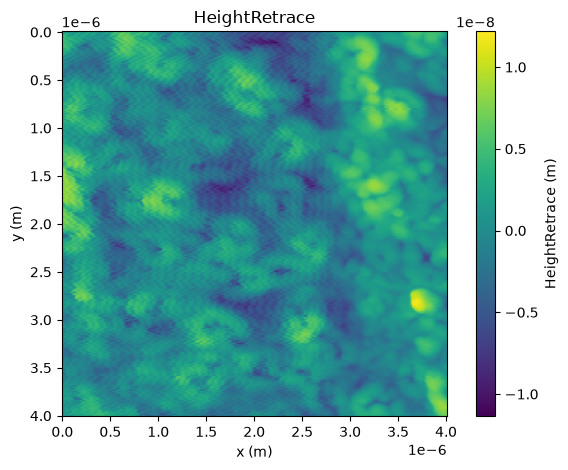

In [6]:
height = tiled_array_to_sidpy(node["Channel_000"])

print(height.title, f"[{height.units}]", height.data_type)
print(height.dim_0)
print(height.dim_1)
print("ScanSize:", height.original_metadata["ScanSize"])

height.plot();

### Whole file (container) to sidpy


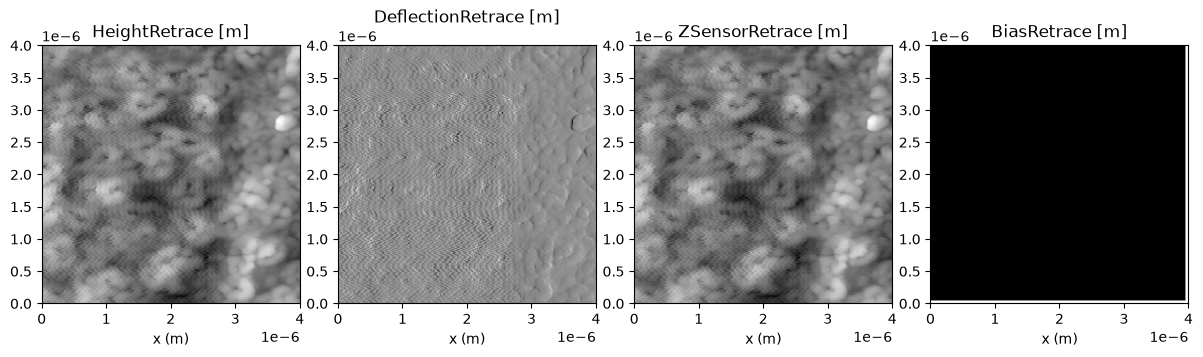

In [7]:
datasets = tiled_container_to_sidpy(node)  # {"Channel_000": sidpy.Dataset, ...}

fig, axes = plt.subplots(1, len(datasets), figsize=(3 * len(datasets), 3.5), squeeze=False)
for ax, dset in zip(axes[0], datasets.values()):
    x, y = dset.dim_0, dset.dim_1
    ax.imshow(np.asarray(dset).T, origin="lower", cmap="gray",
              extent=[x.values[0], x.values[-1], y.values[0], y.values[-1]])
    ax.set_title(f"{dset.title} [{dset.units}]")
    ax.set_xlabel(f"{x.name} ({x.units})")
fig.tight_layout()